In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [27]:
import shutil

shutil.copytree(
    "/content/drive/MyDrive/vehicles",
    "/content/vehicles"
)

'/content/vehicles'

In [28]:
dataset_path = "/content/vehicles"

In [29]:
import os

print(os.listdir(dataset_path))

['Car', 'Van', 'Motorcycle', 'Truck']


In [30]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 13672 images belonging to 4 classes.
Found 3417 images belonging to 4 classes.


In [31]:
print(train_generator.class_indices)

{'Car': 0, 'Motorcycle': 1, 'Truck': 2, 'Van': 3}


In [32]:
print("Training Images :", train_generator.samples)
print("Validation Images :", validation_generator.samples)

Training Images : 13672
Validation Images : 3417


In [33]:
#Building CNN model
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(4, activation='softmax')
])

In [34]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [35]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,716 (2.61 MB)

 Trainable params: 683,716 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8478 - loss: 0.4476 - val_accuracy: 0.9040 - val_loss: 0.2744
Epoch 2/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9189 - loss: 0.2240 - val_accuracy: 0.9438 - val_loss: 0.1454
Epoch 3/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9491 - loss: 0.1440 - val_accuracy: 0.9476 - val_loss: 0.1544
Epoch 4/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9603 - loss: 0.1146 - val_accuracy: 0.9523 - val_loss: 0.1210
Epoch 5/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9694 - loss: 0.0891 - val_accuracy: 0.9769 - val_loss: 0.0651
Epoch 6/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9768 - loss: 0.0694 - val_accuracy: 0.9342 - val_loss: 0.1897
Epoch 7/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9818 - loss: 0.0486 - val_accuracy: 0.9742 - val_loss: 0.0701
Epoch 8/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9857 - loss: 0.0403 - 

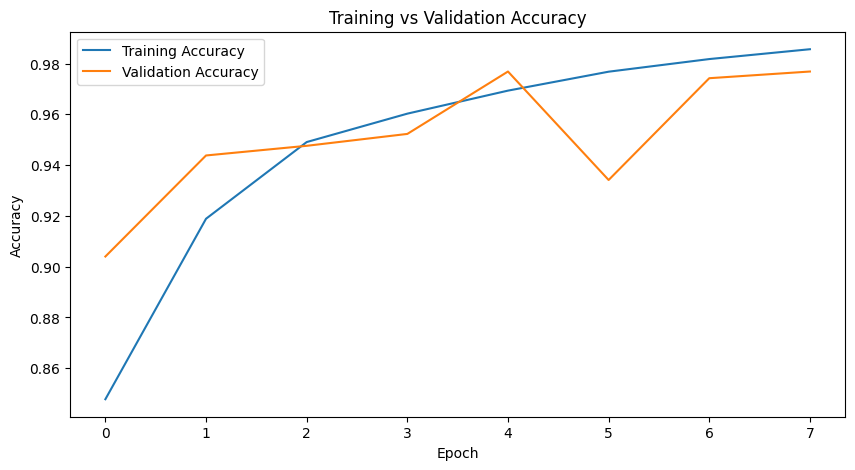

In [37]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

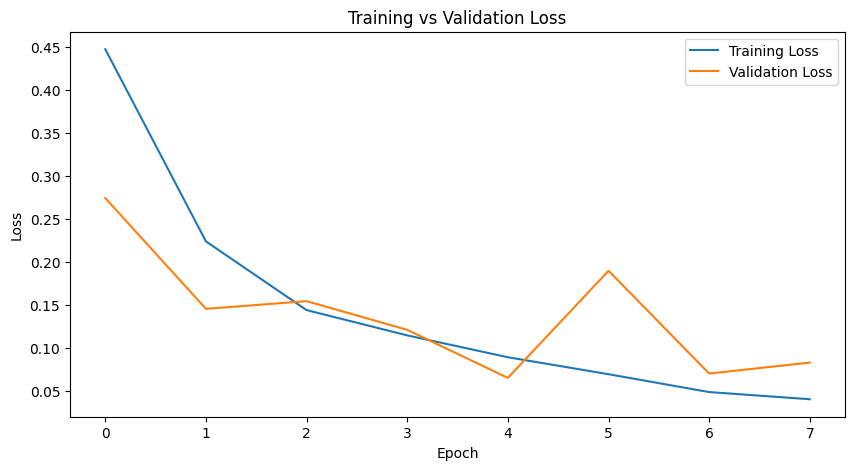

In [38]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [39]:
model.save("vehicle_classifier.keras")

In [40]:
loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9769 - loss: 0.0651
Validation Loss: 0.06505479663610458
Validation Accuracy: 0.9768803119659424


In [41]:
class_names = list(train_generator.class_indices.keys())
print(class_names)

['Car', 'Motorcycle', 'Truck', 'Van']


In [46]:
prediction = model.predict(img_array)

print("Prediction probabilities:", prediction)
print("Predicted Index:", np.argmax(prediction))
print("Predicted Class:", class_names[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediction probabilities: [[5.7434168e-06 9.9995804e-01 3.6158133e-05 1.7763519e-08]]
Predicted Index: 1
Predicted Class: Motorcycle


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


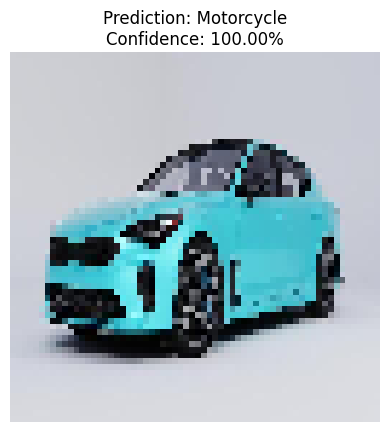

Predicted Class: Motorcycle
Confidence: 100.0


In [56]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/vehicles/Customimg/car3.jpg"

img = image.load_img(img_path, target_size=(64,64))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", confidence)